In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Ensure output folders exist
os.makedirs('results/benign', exist_ok=True)
os.makedirs('results/malignant', exist_ok=True)

print("Libraries loaded. TensorFlow version:", tf.__version__)

Libraries loaded. TensorFlow version: 2.20.0


In [2]:
# 1. Load Data (Assumes folders 'yes' and 'no' are inside 'dataset/')
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    'dataset/',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# 2. Define CNN Architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train
print("Training started...")
model.fit(train_data, epochs=10) # Adjust epochs if you want higher accuracy
model.save('model.h5')
print("Model trained and saved as model.h5")

Found 2400 images belonging to 2 classes.
Training started...


c:\Users\wwwsh\anaconda3\envs\Shuzury_57\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 395ms/step - accuracy: 0.7692 - loss: 0.7051
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 312ms/step - accuracy: 0.9075 - loss: 0.2416
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 288ms/step - accuracy: 0.9538 - loss: 0.1324
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 280ms/step - accuracy: 0.9804 - loss: 0.0760
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 311ms/step - accuracy: 0.9858 - loss: 0.0453
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 265ms/step - accuracy: 0.9904 - loss: 0.0366
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 268ms/step - accuracy: 0.9979 - loss: 0.0135
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 257ms/step - accuracy: 0.9954 - loss: 0.0194
Epoch 9/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 252ms/step - accuracy: 0.9929 - loss: 0.0224
Epoch 10/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 249ms/step - accuracy: 0.9979 - loss: 0.0097


Model trained and saved as model.h5


In [3]:
def process_scans():
    model = tf.keras.models.load_model('model.h5')
    patient_path = 'patient/'
    files = [f for f in os.listdir(patient_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not files:
        print("No new images found in the 'patient' folder.")
        return

    for filename in files:
        img_path = os.path.join(patient_path, filename)
        
        # Prepare image
        img = load_img(img_path, target_size=(150, 150))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        prediction = model.predict(img_array)
        
        # Determine Folder & Label
        if prediction[0] > 0.5:
            label = "Malignant"
            dest = os.path.join('results/malignant', filename)
        else:
            label = "Benign"
            dest = os.path.join('results/benign', filename)

        # Move the file
        shutil.move(img_path, dest)
        print(f"Processed {filename}: Classified as {label}")

process_scans()

No new images found in the 'patient' folder.


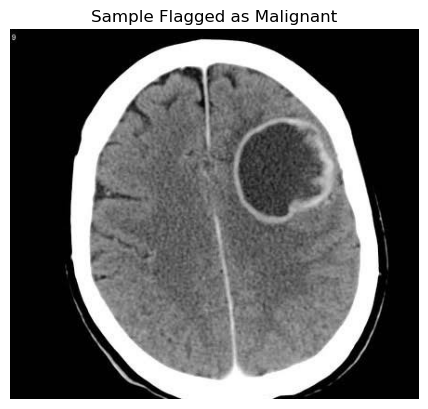

In [4]:
# Show the first image in the malignant folder to verify
mal_folder = 'results/malignant/'
mal_files = os.listdir(mal_folder)

if mal_files:
    sample_img = load_img(os.path.join(mal_folder, mal_files[0]))
    plt.imshow(sample_img)
    plt.title("Sample Flagged as Malignant")
    plt.axis('off')
    plt.show()
else:
    print("No malignant scans to display.")

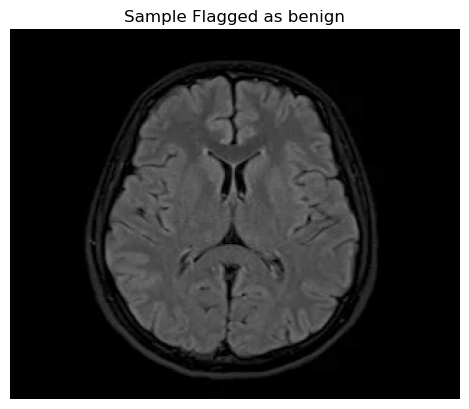

In [5]:
# Show the first image in the malignant folder to verify
mal_folder = 'results/benign/'
mal_files = os.listdir(mal_folder)

if mal_files:
    sample_img = load_img(os.path.join(mal_folder, mal_files[0]))
    plt.imshow(sample_img)
    plt.title("Sample Flagged as benign")
    plt.axis('off')
    plt.show()
else:
    print("No malignant scans to display.")